# Random Forest — IACV

Experimento de Random Forest para predecir violencia atípica basada en el IACV (`atypical_violence_iacv`). Mismas features y splits que `en_iacv.ipynb` para comparación directa con Elastic Net.

Diferencias con Elastic Net:
- No requiere estandarización (paso 6 omitido)
- Captura interacciones no lineales de forma nativa
- `class_weight='balanced'` ajusta los pesos por clase en cada split del árbol

In [ ]:
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

_here = Path().resolve()
_root = _here
while not (_root / 'paths.yml').exists() and _root.parent != _root:
    _root = _root.parent

with open(_root / 'paths.yml') as f:
    _paths = yaml.safe_load(f)

processed = Path(_paths['data']['processed'])
model_out = Path(_paths['outputs']['model'])

sys.path.insert(0, str(_here))

from pipeline import (
    load_data,
    analyze_target,
    create_temporal_splits,
    prepare_features,
    impute_missing,
    tune_rf,
    optimize_threshold,
    evaluate_model,
    get_feature_importance,
    export_results,
    export_predictions,
)

print('pipeline importado correctamente')

---
## CONFIGURACIÓN

In [ ]:
EXPERIMENT_NAME = 'rf_iacv'
MODEL_TYPE      = 'rf'

DATA_PATH   = processed / 'db.parquet'
RESULTS_DIR = model_out / MODEL_TYPE   # outputs/model/rf/
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL       = 'atypical_violence_iacv'
TIME_COL         = 'quarter'
MUNICIPALITY_COL = 'mun_code'

# ── Features: misma lista explícita que en_iacv.ipynb ──────────────────────
FEATURE_COLS = [
    'population', 'dept_code', 'women_share',
    'petroleo_crudo_median', 'cafe_arabica_median', 'oro_median',
    'covid', 'covid_d',
    'ia_r1', 'ia_r2', 'ia_r3', 'ia_r4',
    'igc_r1', 'igc_r2', 'igc_r3', 'igc_r4',
    'iif_r1', 'iif_r2', 'iif_r3', 'iif_r4',
    'iacv_r1', 'iacv_r2', 'iacv_r3', 'iacv_r4',
    't_01_r1', 't_01_r2', 't_01_r3', 't_01_r4',
    't_02_r1', 't_02_r2', 't_02_r3', 't_02_r4',
    't_03_r1', 't_03_r2', 't_03_r3', 't_03_r4',
    't_04_r1', 't_04_r2', 't_04_r3', 't_04_r4',
    't_05_r1', 't_05_r2', 't_05_r3', 't_05_r4',
    't_07_r1', 't_07_r2', 't_07_r3', 't_07_r4',
    't_08_r1', 't_08_r2', 't_08_r3', 't_08_r4',
    't_09_r1', 't_09_r2', 't_09_r3', 't_09_r4',
    't_10_r1', 't_10_r2', 't_10_r3', 't_10_r4',
    't_11_r1', 't_11_r2', 't_11_r3', 't_11_r4',
    't_12_r1', 't_12_r2', 't_12_r3', 't_12_r4',
    't_13_r1', 't_13_r2', 't_13_r3', 't_13_r4',
    't_14_r1', 't_14_r2', 't_14_r3', 't_14_r4',
    't_15_r1', 't_15_r2', 't_15_r3', 't_15_r4',
    't_16_r1', 't_16_r2', 't_16_r3', 't_16_r4',
    't_17_r1', 't_17_r2', 't_17_r3', 't_17_r4',
    'coca', 'amapola',
    'y_corr', 'y_corr_tribut_IyC', 'DF_ing_func', 'DF_deuda',
    'DF_desemp_fisc', 's11_total', 'docen_total', 'alumn_total',
    'nbi_2005', 'nbi_2018', 'IPM_2005', 'IPM_2018',
    'ipm_ledu_p_2005', 'ipm_ledu_p_2018',
    'ipm_analf_p_2005', 'ipm_analf_p_2018',
    'ipm_asisescu_p_2005', 'ipm_asisescu_p_2018',
    'ipm_rezagoescu_p_2005', 'ipm_rezagoescu_p_2018',
    'ipm_serv_pinf_p_2005', 'ipm_serv_pinf_p_2018',
    'ipm_ti_p_2005', 'ipm_ti_p_2018',
    'ipm_templeof_p_2005', 'ipm_templeof_p_2018',
    'ipm_assalud_p_2005', 'ipm_assalud_p_2018',
    'ipm_accsalud_p_2005', 'ipm_accsalud_p_2018',
    'ipm_accagua_p_2005', 'ipm_accagua_p_2018',
    'ipm_excretas_p_2005', 'ipm_excretas_p_2018',
    'ipm_pisos_p_2005', 'ipm_pisos_p_2018',
    'ipm_paredes_p_2005', 'ipm_paredes_p_2018',
    'ipm_hacinam_p_2005', 'ipm_hacinam_p_2018',
    'indrural', 'areaoficialkm2', 'altura',
    'discapital', 'dismdo', 'disbogota', 'distancia_mercado'
]
COLS_TO_EXCLUDE = None

# ── Splits ─────────────────────────────────────────────────────────────────
TRAIN_PROP = 0.70
VAL_PROP   = 0.15
TEST_PROP  = 0.15
USE_YEAR_SPLITS = False

# ── Hiperparámetros RF ─────────────────────────────────────────────────────
PARAM_GRID = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [1, 2],
}
N_CV_SPLITS  = 5
CV_SCORING   = 'f1'
RANDOM_STATE = 42

# ── Threshold ──────────────────────────────────────────────────────────────
THRESHOLD_RANGE  = (0.1, 0.9)
THRESHOLD_STEP   = 0.05
THRESHOLD_METRIC = 'f1'

# ── Imputación ─────────────────────────────────────────────────────────────
NUMERIC_STRATEGY     = 'median'
CATEGORICAL_STRATEGY = 'most_frequent'

print(f'configuracion lista  |  experimento: {EXPERIMENT_NAME}')
print(f'  target  : {TARGET_COL}')
print(f'  modelo  : {MODEL_TYPE}')
print(f'  features: {len(FEATURE_COLS)}')
print(f'  output  : {RESULTS_DIR}')
print(f'  splits  : {TRAIN_PROP:.0%} / {VAL_PROP:.0%} / {TEST_PROP:.0%}')

---
## Paso 1 — Cargar datos

In [3]:
df = load_data(DATA_PATH, time_col=TIME_COL, municipality_col=MUNICIPALITY_COL)
df.head(3)

Cargando datos desde: /Users/juandiegoheredianino/Library/CloudStorage/OneDrive-Universidaddelosandes/early-warning-atypical-violence-forecast/data/processed/db.parquet
✓ Datos cargados: 26,904 filas × 182 columnas
Rango temporal : 2017Q1 → 2022Q4
Periodos únicos: 24 | Municipios: 1121


,mun_code,quarter,population,women_share,petroleo_crudo_mean,petroleo_crudo_median,cafe_arabica_mean,cafe_arabica_median,oro_mean,oro_median,...,areaoficialkm2,altura,discapital,dismdo,disbogota,distancia_mercado,dept_code,año,trimestre,periodo_num
0,05001,2017Q1,2368047.0,0.52995,51.781452,52.690001,144.53629,143.875,1219.658067,1224.150024,...,6075.134367,1475.0,0.000000,0.000000,264.33902,0.000000,05,2017,1,20171
1,05002,2017Q1,20485.0,0.48250,51.781452,52.690001,144.53629,143.875,1219.658067,1224.150024,...,41.315895,2275.0,58.200874,58.200874,209.00545,16.083084,05,2017,1,20171
2,05004,2017Q1,2640.0,0.46364,51.781452,52.690001,144.53629,143.875,1219.658067,1224.150024,...,8.972696,1900.0,63.854633,63.854633,326.94080,49.629030,05,2017,1,20171


---
## Paso 2 — Análisis de la variable objetivo

ANÁLISIS DE VARIABLE OBJETIVO: 'atypical_violence_iacv'
  Clase 1 (positivo): 5,302  (19.71%)
  Clase 0 (negativo): 21,602  (80.29%)
  Desbalance        : 4.07:1


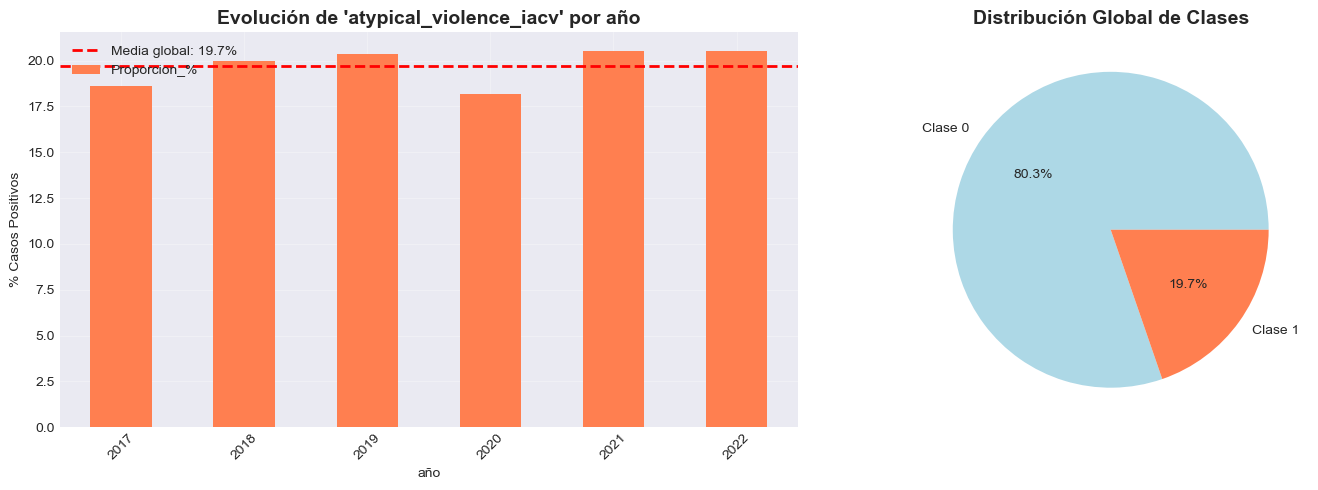

In [4]:
target_stats = analyze_target(df, TARGET_COL, time_group_col='año', plot=True)

---
## Paso 3 — Splits temporales

In [5]:
splits = create_temporal_splits(
    df,
    time_col        = TIME_COL,
    train_prop      = TRAIN_PROP,
    val_prop        = VAL_PROP,
    test_prop       = TEST_PROP,
    use_year_splits = USE_YEAR_SPLITS,
)

train_mask = splits['train_mask']
val_mask   = splits['val_mask']
test_mask  = splits['test_mask']

✓ Splits por proporciones (70%/15%/15%):
  Train: 16 periodos  (2017Q1 → 2020Q4)  17,936 obs (66.7%)
  Val  :  4 periodos  (2021Q1 → 2021Q4)  4,484 obs (16.7%)
  Test :  4 periodos  (2022Q1 → 2022Q4)  4,484 obs (16.7%)
✓ Sin overlap


---
## Paso 4 — Preparar features

In [6]:
X, y, feature_cols = prepare_features(
    df,
    target_col       = TARGET_COL,
    municipality_col = MUNICIPALITY_COL,
    time_col         = TIME_COL,
    cols_to_exclude  = COLS_TO_EXCLUDE,
    feature_cols     = FEATURE_COLS,
)

X_train, y_train = X[train_mask].copy(), y[train_mask].copy()
X_val,   y_val   = X[val_mask].copy(),   y[val_mask].copy()
X_test,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

print(f'\nformas: train={X_train.shape} | val={X_val.shape} | test={X_test.shape}')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name}: prevalencia={yy.mean():.2%}')

FEATURES DEL MODELO
  Features seleccionadas : 137
  Target                 : 'atypical_violence_iacv'  (prevalencia: 19.71%)

  Variables:
      1. population
      2. dept_code
      3. women_share
      4. petroleo_crudo_median
      5. cafe_arabica_median
      6. oro_median
      7. covid
      8. covid_d
      9. ia_r1
     10. ia_r2
     11. ia_r3
     12. ia_r4
     13. igc_r1
     14. igc_r2
     15. igc_r3
     16. igc_r4
     17. iif_r1
     18. iif_r2
     19. iif_r3
     20. iif_r4
     21. iacv_r1
     22. iacv_r2
     23. iacv_r3
     24. iacv_r4
     25. t_01_r1
     26. t_01_r2
     27. t_01_r3
     28. t_01_r4
     29. t_02_r1
     30. t_02_r2
     31. t_02_r3
     32. t_02_r4
     33. t_03_r1
     34. t_03_r2
     35. t_03_r3
     36. t_03_r4
     37. t_04_r1
     38. t_04_r2
     39. t_04_r3
     40. t_04_r4
     41. t_05_r1
     42. t_05_r2
     43. t_05_r3
     44. t_05_r4
     45. t_07_r1
     46. t_07_r2
     47. t_07_r3
     48. t_07_r4
     49. t_08_r1
     50

---
## Paso 5 — Imputación

In [7]:
X_train, X_val, X_test, imputers = impute_missing(
    X_train, X_val, X_test,
    numeric_strategy     = NUMERIC_STRATEGY,
    categorical_strategy = CATEGORICAL_STRATEGY,
)

Columnas numéricas: 136 | Categóricas: 1
Valores faltantes en train: 0
✓ Sin valores faltantes, no se requiere imputación
NaNs restantes: 0


---
## Paso 7 — Búsqueda de hiperparámetros

No se requiere estandarización (paso 6) para modelos basados en árboles. Se pasa directamente a la búsqueda de hiperparámetros.

In [8]:
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

best_model, cv_results = tune_rf(
    X_tv, y_tv,
    param_grid   = PARAM_GRID,
    n_cv_splits  = N_CV_SPLITS,
    scoring      = CV_SCORING,
    random_state = RANDOM_STATE,
    class_weight = 'balanced',
)

GridSearchCV RF: 48 combinaciones × 5 folds | métrica: f1
  class_weight: balanced
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✓ Mejores hiperparámetros:
  max_depth: 5
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 300
  Mejor f1 (CV): 0.3568

Top 5 configuraciones:
param_max_depth  param_min_samples_leaf  param_min_samples_split  param_n_estimators  mean_test_score  std_test_score
              5                       2                       10                 300         0.356844        0.016743
              5                       1                        5                 300         0.356737        0.017013
              5                       2                       10                 500         0.356709        0.017467
              5                       1                       10                 500         0.356699        0.017611
              5                       2                        5                 100         0.356520       

---
## Paso 8 — Optimización de threshold

Threshold óptimo (f1): 0.50
  F1: 0.3985 | Precision: 0.2647 | Recall: 0.8054


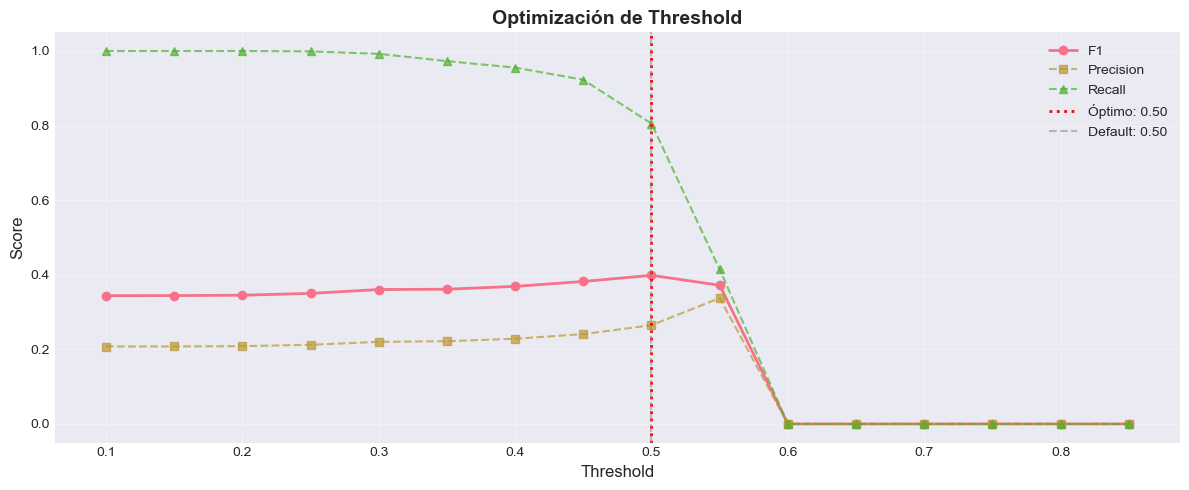

In [9]:
best_threshold, threshold_df = optimize_threshold(
    best_model, X_val, y_val,
    threshold_range  = THRESHOLD_RANGE,
    threshold_step   = THRESHOLD_STEP,
    optimize_metric  = THRESHOLD_METRIC,
    plot             = True,
)

---
## Paso 9 — Evaluación en test

EVALUACIÓN FINAL EN TEST SET
  AUPRC                 : 0.2969
  AUROC                 : 0.6466
  Balanced_Accuracy     : 0.6025
  F1_Score              : 0.3883
  Precision             : 0.2627
  Recall                : 0.7446
  Cohen_Kappa           : 0.1220
  Threshold             : 0.5000

Classification Report:
              precision    recall  f1-score   support

     Clase 0     0.8747    0.4604    0.6033      3564
     Clase 1     0.2627    0.7446    0.3883       920

    accuracy                         0.5187      4484
   macro avg     0.5687    0.6025    0.4958      4484
weighted avg     0.7492    0.5187    0.5592      4484



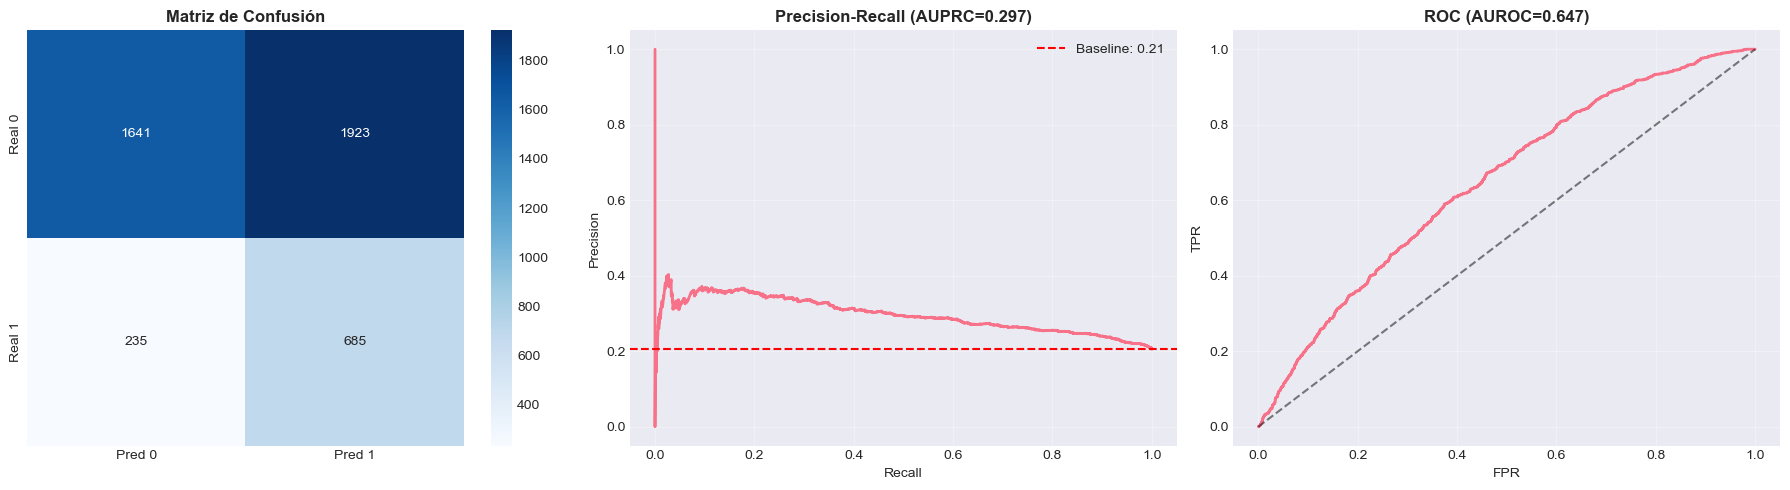

In [10]:
metrics, y_test_proba, y_test_pred = evaluate_model(
    best_model, X_test, y_test,
    threshold = best_threshold,
    plot      = True,
)

---
## Paso 10 — Importancia de features


Features con importancia > 0: 134 / 137

Top 20 features:
              Feature  Importance
           population    0.084963
          docen_total    0.061873
       DF_desemp_fisc    0.060399
               y_corr    0.055020
          DF_ing_func    0.047295
          alumn_total    0.046301
              iacv_r4    0.033995
              t_01_r4    0.028239
              iacv_r2    0.027677
              iacv_r3    0.027269
             indrural    0.026035
              iacv_r1    0.021663
              t_01_r2    0.020816
              t_01_r3    0.020557
       areaoficialkm2    0.015792
petroleo_crudo_median    0.013473
              t_13_r1    0.013037
    distancia_mercado    0.012429
    y_corr_tribut_IyC    0.012019
              t_01_r1    0.011805


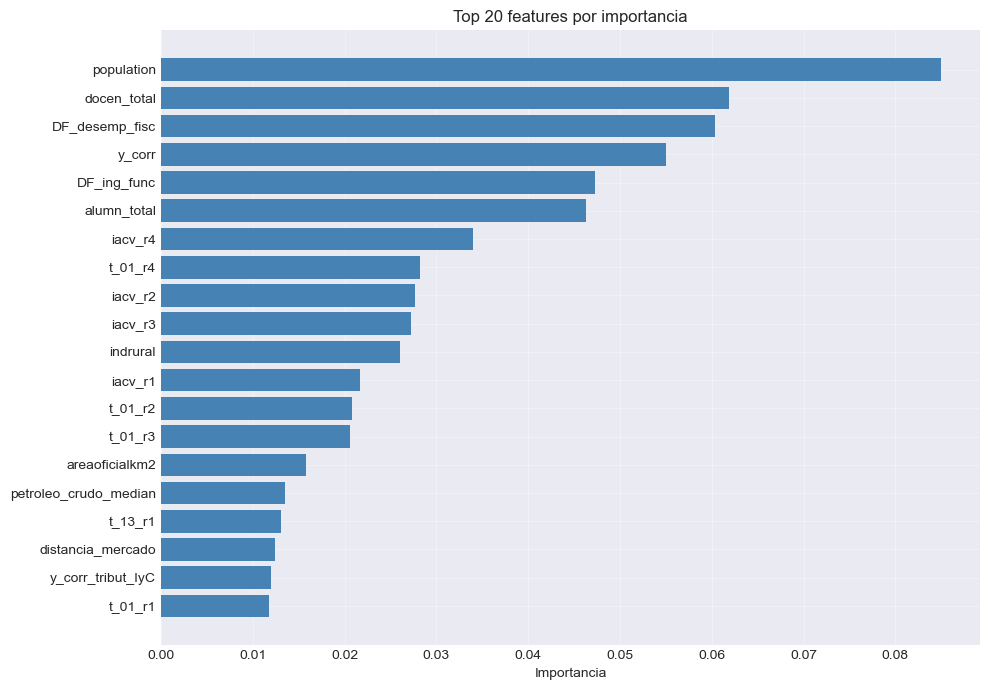

In [11]:
importancia = get_feature_importance(best_model, feature_cols, top_n=20, plot=True)

---
## Paso 11 — Exportar resultados

In [ ]:
output_paths = export_results(
    results_dir     = RESULTS_DIR,
    experiment_name = EXPERIMENT_NAME,
    coeficientes    = importancia,
)

---
## Paso 12 — Exportar predicciones

Exporta las predicciones a nivel observacion en formato estandarizado para el notebook de evaluacion comparativa.

In [ ]:
pred_path = export_predictions(
    results_dir     = RESULTS_DIR,
    experiment_name = EXPERIMENT_NAME,
    model_type      = MODEL_TYPE,
    target_col      = TARGET_COL,
    mun_codes       = df[test_mask][MUNICIPALITY_COL],
    quarters        = df[test_mask][TIME_COL],
    y_true          = y_test,
    y_pred          = y_test_pred,
    y_proba         = y_test_proba,
    threshold       = best_threshold,
)